# Experiment 3

Idea: mask true sensitive attribute label from algorithm

In [ ]:
import copy
from typing import Optional

import gymnasium as gym
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from stable_baselines3.ppo import PPO

from config import (
    CALENDAR_SEED,
    DEMAND_MODEL_PRICE_GRANULARITY,
    FIGURES_PATH,
    N_SNAP_DAYS,
    NOISE_RANGE,
    NUM_PRODUCTS,
    NUM_TIMESTEPS,
    P_DIFF,
    P_MAX,
    P_MIN,
    PPO_HYPERPARAMS,
    PPO_TRAINING_EPISODES,
    RANDOM_SENS_PROBS_LIST,
    SEED_LIST,
    K,
)
from fair_dynamic_pricing_with_rl.utils.demand_model import DemandModelEstimator
from fair_dynamic_pricing_with_rl.utils.env import FMCGEnv
from fair_dynamic_pricing_with_rl.utils.experiment_utils import argmedian
from fair_dynamic_pricing_with_rl.utils.fairness_utils import compute_jains_index


In [2]:
unit_sales = pd.read_csv("../data/sales_train_evaluation.csv")
prices = pd.read_csv("../data/sell_prices.csv")
calendar = pd.read_csv("../data/calendar.csv")

In [3]:
demand_model_estimator = DemandModelEstimator(
    unit_sales_df = unit_sales,
    prices_df = prices,
    calendar_df = calendar,
    price_granularity = DEMAND_MODEL_PRICE_GRANULARITY,
    verbose = False # demand parameters were shown in experiment 1
)

demand_model_parameters = demand_model_estimator.run_pipeline()

## New environment with sensitive attribute inversion

In [4]:
class FMCGEnv3(FMCGEnv):
    def __init__(
        self,
        p_min: np.ndarray,
        p_max: np.ndarray,
        p_diff: np.ndarray,
        betas: list,
        noise_range: int,
        max_demand: int,
        n_snap_days: int,
        calendar_seed=None,
        T: int = 365,
        random_sens_prob: float = 0.5,
    ):
        """Initialize FMCG Gymnasium environment.

        Args:
            p_min (np.array): minimum price vector of products (L)
            p_max (np.array): maximum price vector of products (L)
            p_diff (np.array): price step vector of products (L)
            betas (List[np.ndarray]): demand core state param. for non-SNAP and SNAP households
            noise_range (int): maximum value of noise (symmetric)
            max_demand (int): the maximum daily demand considering all L products
            n_snap_days (int): number of SNAP days in a 30-day month.
            calendar_seed (int, optional): seed used for constructing SNAP calendar
            T (int, optional): length of episode (defaults to 365),
            random_sens_prob (float): probability of inverting sensitive attribute (default: 0.5)
        """
        super().__init__(p_min, p_max,p_diff,
                         betas, noise_range, max_demand, n_snap_days, calendar_seed,
                         T)
        self._random_sens_prob = random_sens_prob

    def reset(self,
              seed: Optional[int] = None,
              options: Optional[dict] = None):
        """Start a new episode.

        Args:
            seed: Random seed for reproducible episodes
            options: Additional configuration

        Returns:
            tuple: (observation, info) for the initial state
        """
        if seed is not None:
            self._flip_rng = np.random.default_rng(np.random.SeedSequence([seed, 1]))
        elif not hasattr(self, "_flip_rng"):
            self._flip_rng = np.random.default_rng()

        # one Bernoulli draw per timestep, fixed for the whole episode
        self._flips = self._flip_rng.random(self.T) < self._random_sens_prob

        # perform FMCGEnv reset
        return super().reset(seed=seed, options=options)

    def _t_to_randomized_sens_attr(
            self,
            t: int,
        ):
            """Returns the sensitive attribute at t, with self.random_sens_attr prob.
            returns the opposite label.
            Args:
                t (int): time step index
    
            Returns
                sensitive attribute: (potentially inversed) sensitive attribute at t (0/1)
            """
            # get true sensitive attribute and get random number
            sens_attr = self.mask[(np.asarray(t)) % 30].astype(int)
            flip = bool(self._flips[t % self.T])

            # (potentially) invert label
            if flip:
                sens_attr = 1 - sens_attr

            return sens_attr

    def _get_obs(self):
        """Convert internal state to observation format.

        Returns:
            obs (dict): Observation with demand and time point
        """
        # apply min-max scaling to demand
        obs = super()._get_obs()
        obs["sensitive_attr"] = int(self._t_to_randomized_sens_attr(self._t))
        return obs

In [5]:
# Register the environment so we can create it with gym.make()
gym.register(
    id="gymnasium_env/FMCGEnv3",
    entry_point=FMCGEnv3,
    max_episode_steps=500,  # Prevent infinite episodes
)

In [ ]:
def running_model(env1,
                  alg,
                  T,
                  K,
                  num_products,
                  seed=None
                  ):
    """ Running PPO algorithm

    Args:
        env1 (FMCGEnv3): the defined gym environment
        alg (stable_baselines3.PPO): PPO policy
        T (int): number of timesteps per episode
        K (int): number of episodes
        num_products (int): number of products
        seed (int): seed for reproducibility

    Returns:
        rew (np.ndarray): rewards (T,K)
        action_hist (np.ndarray): action history (T,K,L)
        groups (np.ndarray): groups according to binary sensitive attribute (T,K)
    """

    env = copy.deepcopy(env1)

    rew = np.zeros((T,K))
    action_hist = np.zeros((T,K,num_products))
    groups = np.zeros((T,K))

    for k in range(K):
        # sample initial state
        # seed each reset deterministically but distinctly per episode
        observation, info = env.reset(seed=None if seed is None else seed + k)

        for t in range(T):
            # save the group wrt. sensitive attribute
            groups[t,k] = observation['sensitive_attr']
            
            # take action using trained model
            action, _states = alg.predict(observation, deterministic=False)
            a = np.asarray(action)
            
            action_hist[t,k] = a

            # record new state/reward from action played
            observation, reward, terminated, truncated, info = env.step(a)

            rew[t,k] = reward
        
    return rew, action_hist, groups

In [ ]:
# storing expected mean episode rewards
episode_rewards_comparison = np.zeros((K*len(RANDOM_SENS_PROBS_LIST),3))
# storing Jain's indexes and mean episode revenues
results = pd.DataFrame(np.zeros((len(RANDOM_SENS_PROBS_LIST),5)),
                       columns=["mean_episode_revenue","jains_index","random_action_prob", "nonsnap_price", "snap_price"])

rewards_over_seeds = np.zeros((len(SEED_LIST),NUM_TIMESTEPS,K))
action_hist_over_seeds = np.zeros((len(SEED_LIST),NUM_TIMESTEPS,K,NUM_PRODUCTS))
groups_over_seeds = np.zeros((len(SEED_LIST),NUM_TIMESTEPS,K))

for idx in range(len(RANDOM_SENS_PROBS_LIST)):
    for seed_idx in range(len(SEED_LIST)):
        # make environment with chosen prob. of inverted sens attr.
        env = gym.make("gymnasium_env/FMCGEnv3",
                p_min=P_MIN,
                p_max=P_MAX,
                p_diff=P_DIFF,
                betas=[params.to_numpy() for params in demand_model_parameters[3]],
                max_demand=demand_model_parameters[4],
                n_snap_days=N_SNAP_DAYS,
                calendar_seed=CALENDAR_SEED,
                noise_range=NOISE_RANGE,
                random_sens_prob=RANDOM_SENS_PROBS_LIST[idx]
                )

        # define and warm-up algorithm
        # PPO hyperparameters from Liu et al. (2024)
        model = PPO(policy="MultiInputPolicy",
                    env=env,
                    learning_rate=PPO_HYPERPARAMS["learning_rate"],
                    batch_size=PPO_HYPERPARAMS["batch_size"], # default
                    clip_range=PPO_HYPERPARAMS["clip_range"], # default
                    seed=PPO_HYPERPARAMS["seed"])

        model.learn(total_timesteps=PPO_TRAINING_EPISODES*NUM_TIMESTEPS,
                    progress_bar=False)

        rewards, action_hist, groups = running_model(env1=env,
                                                alg=model,
                                                T=NUM_TIMESTEPS,
                                                K=K,
                                                num_products=NUM_PRODUCTS,
                                                seed=SEED_LIST[seed_idx])

        rewards_over_seeds[seed_idx, ...] = rewards
        action_hist_over_seeds[seed_idx, ...] = action_hist
        groups_over_seeds[seed_idx, ...] = groups

    # choose based on median of last episode reward
    last_episode_rewards_over_seeds = rewards_over_seeds.sum(axis=1)[:,-1]
    median_seed_idx = argmedian(last_episode_rewards_over_seeds)

    rewards_chosen = rewards_over_seeds[median_seed_idx,...]
    action_hist_chosen = action_hist_over_seeds[median_seed_idx,...]
    groups_chosen = groups_over_seeds[median_seed_idx,...]
    
    episode_rewards = rewards_chosen.sum(axis=0)
    e_mean_episode_reward = episode_rewards.cumsum() / (np.arange(K) + 1)

    # expected mean episode rewards
    episode_rewards_comparison[(idx*K):((idx+1)*K),0] = np.arange(K)
    episode_rewards_comparison[(idx*K):((idx+1)*K),1] = e_mean_episode_reward

    # random action probability
    episode_rewards_comparison[(idx*K):((idx+1)*K),2] = RANDOM_SENS_PROBS_LIST[idx]

    # save main performance metrics
    results.loc[idx,"random_sens_prob"] = RANDOM_SENS_PROBS_LIST[idx]
    results.loc[idx,"mean_episode_revenue"] = episode_rewards.mean()
    results.loc[idx, "jains_index"], group_values = compute_jains_index(action_hist_chosen,
                                                                        groups_chosen,
                                                                        p_min=P_MIN,
                                                                        p_diff=P_DIFF)
    results.loc[idx, "nonsnap_price"] = group_values[False]
    results.loc[idx, "snap_price"] = group_values[True]

In [8]:
# save & print results, note the Windows-specific path(!)
results.to_csv("..\\output\\experiment_3\\results.csv",
               index=False)
results

,mean_episode_revenue,jains_index,random_action_prob,nonsnap_price,snap_price,random_sens_prob
0,10012.371562,0.994906,0.0,11.945484,13.786842,0.000000
1,10469.037530,0.994376,0.0,12.029801,13.986328,0.111111
2,10193.919156,0.996697,0.0,12.246745,13.743007,0.222222
3,10370.636058,0.996847,0.0,12.223887,13.680813,0.333333
4,10060.694765,0.997380,0.0,12.288013,13.615566,0.444444
5,10116.909647,0.997162,0.0,12.160308,13.530940,0.555556
6,9902.575025,0.997989,0.0,12.316646,13.474403,0.666667
7,9640.121643,0.997628,0.0,12.276074,13.534658,0.777778
8,9691.316576,0.997052,0.0,12.423717,13.852521,0.888889
9,9557.007160,0.997466,0.0,12.518126,13.846940,1.000000


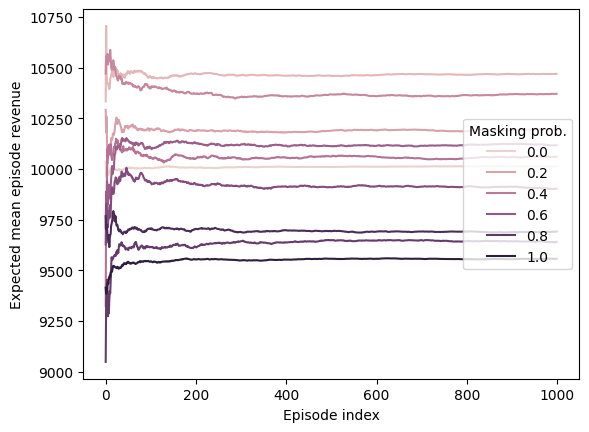

In [9]:
episode_rewards_comparison_df = pd.DataFrame(episode_rewards_comparison,
                                             columns=["episode_idx", "mean_episode_revenue", "random_sens_prob"])

# for plotting every episode ex. first x: data = episode_rewards_comparison_df.loc[episode_rewards_comparison_df.episode_idx > 50.0],
sns.lineplot(data = episode_rewards_comparison_df,
             x="episode_idx",
             y="mean_episode_revenue",
             hue="random_sens_prob")
plt.xlabel("Episode index")
plt.ylabel("Expected mean episode revenue")
plt.legend(title="Masking prob.", loc="center right")
plt.savefig(FIGURES_PATH + "experiment_3_revenue_over_time.pdf", format="pdf", bbox_inches="tight")

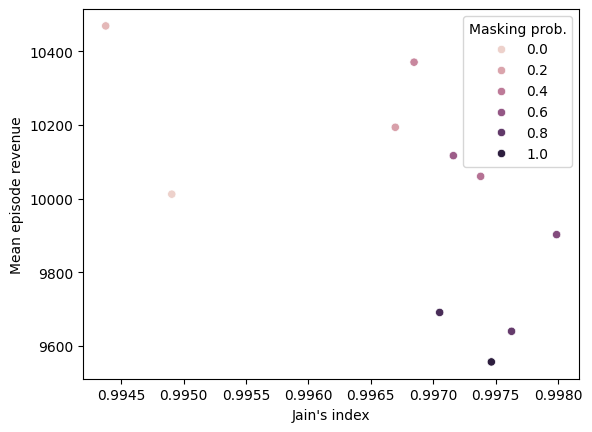

In [10]:
sns.scatterplot(data=results, x="jains_index", y="mean_episode_revenue",
                hue="random_sens_prob")
plt.xlabel("Jain's index")
plt.ylabel("Mean episode revenue")
plt.legend(title="Masking prob.", loc="upper right")
plt.savefig(FIGURES_PATH + "experiment_3_revenue_vs_jains.pdf", format="pdf", bbox_inches="tight")